In [259]:
import numpy as np
from scipy.integrate import *
import matplotlib.pyplot as plt 
import math

In [260]:
def system(t, variables, param_cav, param_mol):
    xc, vc, xm, vm = variables
    wc, k, E = param_cav
    wm, lamb, gamma = param_mol

    dxcdt = vc
    dvcdt = E*np.cos(wc*t) - k*vc -xc*wc**2
    dxmdt = vm 
    dvmdt = -xm*wm**2 -lamb*vm - gamma*xm*xc
    return [dxcdt, dvcdt, dxmdt,dvmdt]

In [261]:
# set up parameters 
param_cav = [1, 0.1, 1] # wc, k, E
param_mol = [1, 0.1, 1] # wm, lamb, gamma

# set up initial conditions: 

init_cond = [1, 0, 1, 0]
time_points = np.linspace(0, 10, 100)  # Time points from 0 to 10


In [262]:
# Solve
solution = solve_ivp(system, [time_points[0], time_points[-1]], init_cond, method='DOP853',
                     t_eval=time_points, args=(param_cav, param_mol), rtol=1e-10, atol=1e-10)


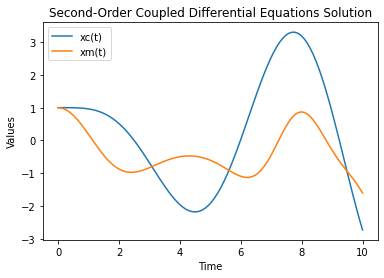

In [263]:
# Extract the solutions for xc and xm
xc_values = solution.y[0]
xm_values = solution.y[2]

# Plot the results
plt.plot(time_points, xc_values, label='xc(t)')
plt.plot(time_points, xm_values, label='xm(t)')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Second-Order Coupled Differential Equations Solution')
plt.show()

Try the same with the Velocty-Verlet algorithm. First

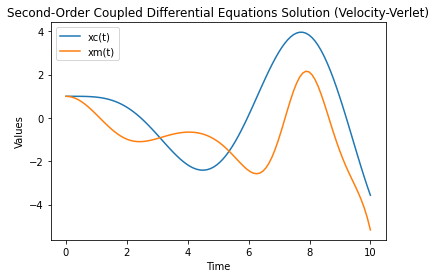

In [264]:
# Define the acceleration function for the system
def acceleration(xc, vc, xm, vm, param_cav, param_mol, t):
    wc, k, E = param_cav
    wm, lamb, gamma = param_mol
    
    a_xc = E * np.cos(wc * t) - k * vc - xc * wc ** 2
    a_xm = -xm * wm ** 2 - lamb * vm - gamma * xm * xc
    
    return np.array([a_xc, a_xm])


# Define the Velocity-Verlet algorithm
def velocity_verlet(init_cond, time_points, param_cav, param_mol):
    n_points = len(time_points)
    dt = time_points[1] - time_points[0]
    
    # Initialize arrays to store positions and velocities
    xc_values = np.zeros(n_points)
    vc_values = np.zeros(n_points)
    xm_values = np.zeros(n_points)
    vm_values = np.zeros(n_points)
    
    # Set initial conditions
    xc_values[0], vc_values[0], xm_values[0], vm_values[0] = init_cond
    
    for i in range(n_points - 1):
        t = time_points[i]
        
        # Calculate current accelerations
        a_xc, a_xm = acceleration(xc_values[i], vc_values[i], xm_values[i], vm_values[i], param_cav, param_mol, t)
        
        # Update positions
        xc_values[i + 1] = xc_values[i] + vc_values[i] * dt + 0.5 * a_xc * dt ** 2
        xm_values[i + 1] = xm_values[i] + vm_values[i] * dt + 0.5 * a_xm * dt ** 2
        
        # Calculate new accelerations at the new positions
        a_xc_new, a_xm_new = acceleration(xc_values[i + 1], vc_values[i], xm_values[i + 1], vm_values[i], param_cav, param_mol, t + dt)
        
        # Update velocities
        vc_values[i + 1] = vc_values[i] + 0.5 * (a_xc + a_xc_new) * dt
        vm_values[i + 1] = vm_values[i] + 0.5 * (a_xm + a_xm_new) * dt
    
    return xc_values, vc_values, xm_values, vm_values

# Set up parameters
param_cav = [1, 0, 1]  # wc, k, E
param_mol = [1, 0, 1]  # wm, lamb, gamma

# Set up initial conditions
init_cond = [1, 0, 1, 0]
time_points = np.linspace(0, 10, 100)  # Time points from 0 to 10

# Solve the system using Velocity-Verlet algorithm
xc_values, vc_values, xm_values, vm_values = velocity_verlet(init_cond, time_points, param_cav, param_mol)

# Plot the results
plt.plot(time_points, xc_values, label='xc(t)')
plt.plot(time_points, xm_values, label='xm(t)')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Second-Order Coupled Differential Equations Solution (Velocity-Verlet)')
plt.show()

Try to code it like in Tuckerman, 15.5.17

The time evolution of our light-matter coupled system is described by the following linearly coupled equations of motions:

$a_{c} = \ddot{x}_{c} = - \omega_{c}^{2}x_{c} + E_{0}cos(\omega_{L}t) - k\dot{x}_{c} $

$a_{m} = \ddot{x}_{m} = - \omega_{m}^{2}x_{m} - \lambda_{m}\dot{x}_{m}  - \eta(t) - \gamma x_{c}x_{m}$

whereby the first terms (rhs) in both equations corresponds to the forces.


These equations correspond to the differential equation found in Tuckerman, (15.5.5):

$ dv(t) = f(q(t))dt - \gamma v(t) dt + \sigma dw(t)$.

One needs to be careful, because the forces, therefore the accelerations, in the equations in Tuckerman do not include the velocity term and the random kicks. I am not sure whether these terms should be included or not in the definition of the acceleration function. I think not. 

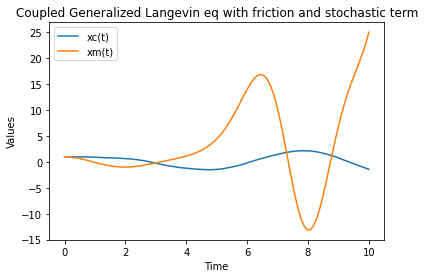

In [265]:
# Define the acceleration function for the system
def acceleration(xc, vc, xm, vm, param_cav, param_mol, t):
    wc, E = param_cav
    wm, gamma = param_mol
    
    a_xc = E * np.cos(wc * t)  - xc * wc ** 2
    a_xm = -xm * wm ** 2  - gamma * xm * xc
    
    return np.array([a_xc, a_xm])



# Define the Velocity-Verlet algorithm
def velocity_verlet(init_cond, time_points, param_cav, param_mol):
    n_points = len(time_points)
    dt = time_points[1] - time_points[0]
    
    # Initialize arrays to store positions and velocities
    xc_values = np.zeros(n_points)
    vc_values = np.zeros(n_points)
    xm_values = np.zeros(n_points)
    vm_values = np.zeros(n_points)
    
    # Set initial conditions
    xc_values[0], vc_values[0], xm_values[0], vm_values[0] = init_cond
    
    for i in range(n_points - 1):
        t = time_points[i]
        
       
        # Calculate current accelerations
        a_xc, a_xm = acceleration(xc_values[i], vc_values[i], xm_values[i], vm_values[i], param_cav, param_mol, t)
        
        # Update positions
        xc_values[i + 1] = xc_values[i] + vc_values[i] * dt + 0.5 * (a_xc -k*vc_values[i]) * dt ** 2 + sigma_c*dt**(3/2) * np.random.normal(0.0,1,1)
        xm_values[i + 1] = xm_values[i] + vm_values[i] * dt + 0.5 * (a_xm -lamb*vm_values[i]) * dt ** 2 + sigma_m*dt**(3/2) * np.random.normal(0.0,1,1)
        
        # Calculate new accelerations at the new positions
        a_xc_new, a_xm_new = acceleration(xc_values[i + 1], vc_values[i], xm_values[i + 1], vm_values[i], param_cav, param_mol, t + dt)
        
        # Update velocities
        vc_values[i + 1] = vc_values[i] + 0.5 * (a_xc + a_xc_new) * dt -k*vc_values[i] + sigma_c*np.sqrt(dt)*np.random.normal(0.1,1,1) - k*0.5*dt**2 * (a_xc-k*vc_values[i]) + sigma_c*dt**(3/2) * np.random.normal(0.0,1,1)
        vm_values[i + 1] = vm_values[i] + 0.5 * (a_xm + a_xm_new) * dt -lamb*vm_values[i] + sigma_m*np.sqrt(dt)*np.random.normal(0.1,1,1) - lamb*0.5*dt**2 * (a_xm-lamb*vm_values[i]) + sigma_m*dt**(3/2) * np.random.normal(0.0,1,1)
    
    return xc_values, vc_values, xm_values, vm_values

# Set up parameters
param_cav = [1, 1]  # wc, E
param_mol = [1, 2]  # wm, gamma

# Set up friction coefficients k,lamb and random kick sigma: 
k    = 0.03
lamb = 0.01
kT   = 0.7 # room temperature energy 25,7 meV
mu   = 1
sigma_c = np.sqrt(2*kT*k/mu)
sigma_m = np.sqrt(2*kT*lamb/mu)

# Set up initial conditions
init_cond = [1, 0, 1, 0]
time_points = np.linspace(0, 10, 100)  # Time points from 0 to 10

# Solve the system using Velocity-Verlet algorithm
xc_values, vc_values, xm_values, vm_values = velocity_verlet(init_cond, time_points, param_cav, param_mol)

# Plot the results
plt.plot(time_points, xc_values, label='xc(t)')
plt.plot(time_points, xm_values, label='xm(t)')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Coupled Generalized Langevin eq with friction and stochastic term')
plt.show()

Modified script to include 10 molecules: 

[1.1251239597186091, 1.156126950505526, 1.3065964376741421, 1.1949249696867703, 1.10142322971833, 1.1703246384559782, 1.260025083409058, 1.1153136123120282, 1.2817108873750611]


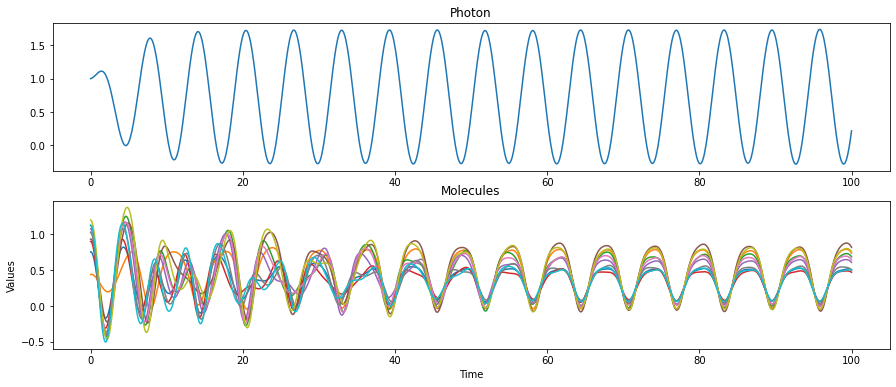

In [266]:
# Define the acceleration function for the system
def acceleration(xc, vc, xm_values, vm_values, param_cav, param_mol, t):
    wc, E = param_cav
    wm = param_mol[0:9]
    gamma = param_mol[-1]
    
    a_xc = E * np.cos(wc * t) - xc * wc ** 2
    
    a_xm_values = np.zeros(10)
    for i in range(10):
        a_xm_values[i] = -xm_values[i] * wm[i-1]** 2 - gamma * xm_values[i] * xc
    
    return a_xc, a_xm_values

# Define the Velocity-Verlet algorithm
def velocity_verlet(init_cond, time_points, param_cav, param_mol):
    n_points = len(time_points)
    dt = time_points[1] - time_points[0]
    
    # Initialize arrays to store positions and velocities
    xc_values = np.zeros(n_points)
    vc_values = np.zeros(n_points)
    xm_values = np.zeros((10, n_points))
    vm_values = np.zeros((10, n_points))
    
    # Set initial conditions
    xc_values[0], vc_values[0] = init_cond[:2]
    xm_values[:, 0], vm_values[:, 0] = init_cond[2:12], init_cond[12:22]
    
    for i in range(n_points - 1):
        t = time_points[i]
        
        # Calculate current accelerations
        a_xc, a_xm_values = acceleration(xc_values[i], vc_values[i], xm_values[:, i], vm_values[:, i], param_cav, param_mol, t)
        
        # Update positions
        xc_values[i + 1] = xc_values[i] + vc_values[i] * dt + 0.5 * (a_xc - k * vc_values[i]) * dt ** 2 + sigma * dt ** (3 / 2) * np.random.normal(1, 0.02, 1)
        for j in range(10):
            xm_values[j, i + 1] = xm_values[j, i] + vm_values[j, i] * dt + 0.5 * (a_xm_values[j] - lamb * vm_values[j, i]) * dt ** 2 + sigma * dt ** (3 / 2) * np.random.normal(1, 0.02, 1)
        
        # Calculate new accelerations at the new positions
        a_xc_new, a_xm_values_new = acceleration(xc_values[i + 1], vc_values[i], xm_values[:, i + 1], vm_values[:, i], param_cav, param_mol, t + dt)
        
        # Update velocities
        vc_values[i + 1] = vc_values[i] + 0.5 * (a_xc + a_xc_new) * dt - k * vc_values[i]*dt + sigma * np.sqrt(dt) * np.random.normal(1, 0.02, 1) - k * 0.5 * dt ** 2 * (a_xc - k * vc_values[i]) + sigma * dt ** (3 / 2) * np.random.normal(1, 0.02, 1)
        for j in range(10):
            vm_values[j, i + 1] = vm_values[j, i] + 0.5 * (a_xm_values[j] + a_xm_values_new[j]) * dt - lamb * vm_values[j, i]*dt + sigma * np.sqrt(dt) * np.random.normal(1, 0.02, 1) - lamb * 0.5 * dt ** 2 * (a_xm_values[j] - lamb * vm_values[j, i]) + sigma * dt ** (3 / 2) * np.random.normal(1, 0.02, 1)
    
    return xc_values, vc_values, xm_values, vm_values

# Set up parameters
param_cav = [1, 0.5]  # wc, E
freqs = np.random.normal(1.2,0.1,10)  # wm
param_mol = freqs.tolist() + [0.9] # wm, gamma

print(param_mol[0:9])
# Set up friction coefficients k, lamb and random kick sigma: 
k = 0.5
lamb = 0.1
sigma = 0.2

# User-defined initial conditions for xc, vc, xm1, ..., xm10, vm1, ..., vm10
init_xc = 1
init_vc = 0
init_xm = np.random.normal(1, 0.3, 10)
init_vm = np.random.normal(0, 0.0, 10)

# Combine initial conditions into a single list
init_cond = [init_xc, init_vc] + init_xm.tolist() + init_vm.tolist()

# Define time points
time_points = np.linspace(0, 100, 1000)  # Time points from 0 to 10

# Solve the system using Velocity-Verlet algorithm
xc_values, vc_values, xm_values, vm_values = velocity_verlet(init_cond, time_points, param_cav, param_mol)

# Plot the results
plt.figure(figsize=[15,6])
plt.title('Coupled Generalized Langevin eq with friction and stochastic term')

plt.subplot(2,1,1)
plt.title('Photon')
plt.plot(time_points, xc_values, label='xc(t)')
plt.subplot(2,1,2)
plt.title('Molecules')
for i in range(10):
    plt.plot(time_points, xm_values[i], label=f'xm{i+1}(t)')
plt.xlabel('Time')
plt.ylabel('Values')

#plt.legend()

plt.show()



I think I see some synchronization with the following parameters: 

Initial frequencies of the molecular oscillators: [1.208714235643063, 1.2561230007154145, 1.212525598296155, 1.441421437169895, 1.1231861340345097, 1.3287604961236976, 1.314736889000854, 1.028997950410273, 1.0276226302783362]

k = 0.5, lamb= 0.1, sigma = 0.2, gamma = 0.9, param_cav= [1, 0.05]


-----------------------------------------------------------------------------------------------------------------------------------------

Now, instead of a bilinear coupling in the equations of motion of the molecules, I derive the classical equation of motion from the "classical" Pauli-Fierz Hamiltonian, under the assumptions that the dipoles of the molecules are linear ($d_{m} = d_{0}x_{m}$):  



$a_{c} = \ddot{x}_{c} = - \omega_{c}^{2}x_{c} - w_{c} \Lambda d_{0} \sum_{m} x_{m} $

$a_{m} = \ddot{x}_{m} = - \omega_{m}^{2}x_{m} - w_{c} \Lambda d_{0} x_{c} - \frac{\Lambda^{2}}{2} d_{0}^{2} \sum_{j} x_{j}  $.

Now, we can add driving, dissipation and random kicks to obtain some Langevin-type model: 

$a_{c} = \ddot{x}_{c} = - \omega_{c}^{2}x_{c} + E_{0}cos(\omega_{L}t) -\kappa \dot{x}_{c} - \eta_{c}(t) - w_{c} \Lambda d_{0} \sum_{m} x_{m} $

$a_{m} = \ddot{x}_{m} = - \omega_{m}^{2}x_{m} - \lambda_{m} \dot{x}_{c} - \eta_{m}(t) - w_{c} \Lambda d_{0}  x_{c}- \frac{\Lambda^{2}}{2} d_{0}^{2} \sum_{j} x_{j} $,

where we can redefine $\gamma = w_{c} \Lambda d_{0}$, and the above equations become:

$a_{c} = \ddot{x}_{c} = - \omega_{c}^{2}x_{c} + E_{0}cos(\omega_{L}t) -\kappa \dot{x}_{c} -  \eta_{c}(t) - \gamma \sum_{m} x_{m} $

$a_{m} = \ddot{x}_{m} = - \omega_{m}^{2}x_{m} - \lambda_{m} \dot{x}_{c} - \eta_{m}(t) - \gamma x_{c} - \frac{\gamma^{2}}{2\omega_{c}^2} \sum_{j} x_{j} $,



These equations correspond to the differential equation found in Tuckerman, (15.5.5):

$ dv(t) = f(q(t))dt - \gamma v(t) dt + \sigma dw(t)$.

One needs to be careful, because the forces, therefore the accelerations, in the equations in Tuckerman do not include the velocity term and the random kicks. I am not sure whether these terms should be included or not in the definition of the acceleration function. I think not. 

In [1]:
import numpy as np
from scipy.integrate import *
import matplotlib.pyplot as plt 
import math

In [2]:
# Define the acceleration function for the system
def acceleration(xc, vc, xm_values, vm_values, num_mol, param_cav, param_mol, t):
    wc, E = param_cav
    wm = param_mol[0:num_mol]
    gamma = param_mol[-1]
    

    a_xc = E * np.cos(wc * t) - xc * wc**2  - gamma *(np.sum(xm_values)) #- k * vc
    
    a_xm_values = np.zeros(num_mol)
    for i in range(num_mol):
        a_xm_values[i] = E * np.cos(0.0161 * t) -xm_values[i] * wm[i-1]** 2  - gamma * xc - gamma**2/(2*wc**2) *(np.sum(xm_values))
    
    return a_xc, a_xm_values

# Define the Velocity-Verlet algorithm
def velocity_verlet(init_cond, time_points, num_mol, param_cav, param_mol):
    n_points = len(time_points)
    dt = time_points[1] - time_points[0]
    
    # Initialize arrays to store positions and velocities
    xc_values = np.zeros(n_points)
    vc_values = np.zeros(n_points)
    xm_values = np.zeros((num_mol, n_points))
    vm_values = np.zeros((num_mol, n_points))
    
    # Set initial conditions
    xc_values[0], vc_values[0] = init_cond[:2]
    xm_values[:, 0], vm_values[:, 0] = init_cond[2:num_mol+2], init_cond[num_mol+2:(num_mol+2)+num_mol]
    
    for i in range(n_points - 1):
        t = time_points[i]
        
        # Calculate current accelerations
        a_xc, a_xm_values = acceleration(xc_values[i], vc_values[i], xm_values[:, i], vm_values[:, i], num_mol, param_cav, param_mol, t)
        
        # Update positions
        R_c = sigma_c * dt**(3 / 2) * (0.5*np.random.normal(0.0, 1.0, 1) + 1/(2*np.sqrt(3))*np.random.normal(0.0, 1.0, 1)) # xi and theta
        #print('current xm_values[:,i]:', xm_values[:,i])
        xc_values[i + 1] = xc_values[i] + vc_values[i] * dt + 0.5 * (a_xc - k * vc_values[i]) * dt**2  + R_c

        for j in range(num_mol):
            R_m = sigma_m * dt ** (3 / 2) * (0.5*np.random.normal(0.0, 1.0, 1) + 1/(2*np.sqrt(3))*np.random.normal(0.0, 1.0, 1))  # xi and theta
            #print('current R_m:', R_m)
            xm_values[j, i + 1] = xm_values[j, i] + vm_values[j, i] * dt + 0.5 * (a_xm_values[j] - lamb * vm_values[j, i]) * dt ** 2 + R_m.item()
        
        # Calculate new accelerations at the new positions
        a_xc_new, a_xm_values_new = acceleration(xc_values[i + 1], vc_values[i], xm_values[:, i + 1], vm_values[:, i], num_mol, param_cav, param_mol, t + dt)
        
        # Update velocities
        vc_values[i + 1] = vc_values[i] + 0.5 * (a_xc + a_xc_new) * dt - k * vc_values[i]*dt + sigma_c * np.sqrt(dt) * np.random.normal(0.0, 1.0, 1).item() - k *(0.5 * dt ** 2 * (a_xc - k * vc_values[i]) + R_c.item())
        for j in range(num_mol):
            vm_values[j, i + 1] = vm_values[j, i] + 0.5 * (a_xm_values[j] + a_xm_values_new[j]) * dt - lamb * vm_values[j, i]*dt + sigma_m * np.sqrt(dt) * np.random.normal(0.0, 1.0, 1).item() - lamb * (0.5 * dt ** 2 * (a_xm_values[j] - lamb * vm_values[j, i]) + R_m.item())
    
    return xc_values, vc_values, xm_values, vm_values


def check_temperature_consistency(vc_values, vm_values, kT, num_mol):
    """
    This function checks if the time-averaged velocities (photon + molecules) are consistent with the initial temperature.
    
    Parameters:
    - vc_values: Array of photon velocities (1D array).
    - vm_values: Array of molecular velocities (2D array, each row corresponds to a molecule).
    - kT: The value of k_B * T (in atomic units).
    - num_mol: Number of molecules.
    
    Returns:
    - Consistency check for the system (photon + molecules).
    """
    
    # Calculate the time-averaged <v^2> for the photon
    v2_photon = np.mean(vc_values[-40000:] ** 2)

    # Calculate the time-averaged <v^2> for each molecule
    v2_molecules = np.zeros(num_mol)

    for j in range(num_mol):
        v2_molecules[j] = np.mean(vm_values[j, -40000:] ** 2)  # Average over time for each molecule
    
    # Average <v^2> across all molecules
    avg_v2_molecules = np.mean(v2_molecules)



    # Combine the photon and molecule contributions
    total_avg_v2 = (v2_photon + avg_v2_molecules * num_mol) / (num_mol + 1)
    
    print("Time-averaged <v^2> for photon:", v2_photon)
    print("Average <v^2> for molecules:", avg_v2_molecules)
    print("Combined average <v^2> for system (photon + molecules):", total_avg_v2)
    print("Expected <v^2> from temperature (kT):", kT)
    
    # Compare with the expected value from temperature (kT)
    system_consistent = np.isclose(total_avg_v2, kT, rtol=0.1)

    if system_consistent:
        print("The time-averaged velocities of the photon and molecules are consistent with the initial temperature.")
    else:
        print("The time-averaged velocities of the photon and molecules are NOT consistent with the initial temperature.")

    return system_consistent



Now, let's set upt some realistic frequencies for molecular vibrations. We turn on the coupling and we observe what happens to the frequencies.

First, run an equilibration step to generate adequate initial conditions. The equilibration step does not have any parametric driving of the cavity, $E_{0} = 0$.

The friction constant of the photon corresponds to the decay rate and is thus inversily proportional to the mean photon lifetime. I chose a value of $\kappa$ based on the cavity parameters used by Marissa Weichman, but I chose a particularly low Finesse to have a shorter photon lifetime and limit the propagation time needed for my simulations. 

$\tau_{ph} = \frac{F\cdot L}{\pi c}$, where $L=8.36 cm$

In [3]:
''' PARAMETERS '''

# Set up number of molecules:
num_mol = 1

# Set up parameters
wc = 0.0151 
wm = 0.0161 # freqs au of the CH sym stretch in CHCl3
E0 = 0.0 #0.00009 #0.0005 # Amplitude of driving laser
param_cav = [wc, E0]  # wc, E
freqs = np.random.normal(wm, 0.000, num_mol)  # wm
print('freqs', freqs)
gamma = 0.0000/np.sqrt(num_mol) # light-matter coupling
param_mol = freqs.tolist() + [gamma] # wm, gamma

# Set up friction coefficients k, lamb and random kick sigma: 
k    = 5.46e-5
lamb = 5.46e-5
kT   = 0.000944*0.01 # 9.44x10⁻4 au is value of room temperature energy 25,7 meV
beta = 1/kT
mu   = 1
sigma_c = np.sqrt(2*kT*k/mu)
sigma_m = np.sqrt(2*kT*lamb/mu)



freqs [0.01588354]


Definie initial conditions for molecules and photon for the equilibration run. These initial conditions are not very relevant, because once the system thermalizes, it loses memory of its initial state.
The molecular oscillators are sampled from two separate Boltzmann distributions. The photon's position and velocities are sample from an acion-angle picture. 

In [4]:
''' Initial conditions'''

# Molecules
std_x = 1/np.sqrt(beta)
std_v = 1/np.sqrt(beta * wm**2)*0.1

init_xm = np.random.normal(0, std_x, num_mol)
init_vm = np.random.normal(0, std_v, num_mol)

# Photon
I = 3*wc/2 # energy when cavity excited with one photon
theta = np.random.uniform(0, 2*np.pi,1).item()

init_xc = np.sqrt(2 * I / (wc)) * np.sin(theta)
init_vc = np.sqrt(2 * I * wc) * np.cos(theta) * 0.1

# Combine initial conditions into a single list
init_cond = [init_xc, init_vc] + init_xm.tolist() + init_vm.tolist()


# Define time pointsp
time_points = np.arange(0, 2000000, 10)  # Time points from 0 to 10

# Solve the system using Velocity-Verlet algorithm
xc_values_eq, vc_values_eq, xm_values_eq, vm_values_eq = velocity_verlet(init_cond, time_points, num_mol, param_cav, param_mol)

# Solve the uncoupled system for comparison
#param_mol = freqs.tolist() + [0]
#xc_values_u, vc_values_u, xm_values_u, vm_values_u = velocity_verlet(init_cond, time_points, num_mol, param_cav, param_mol)




Plot equilibration run

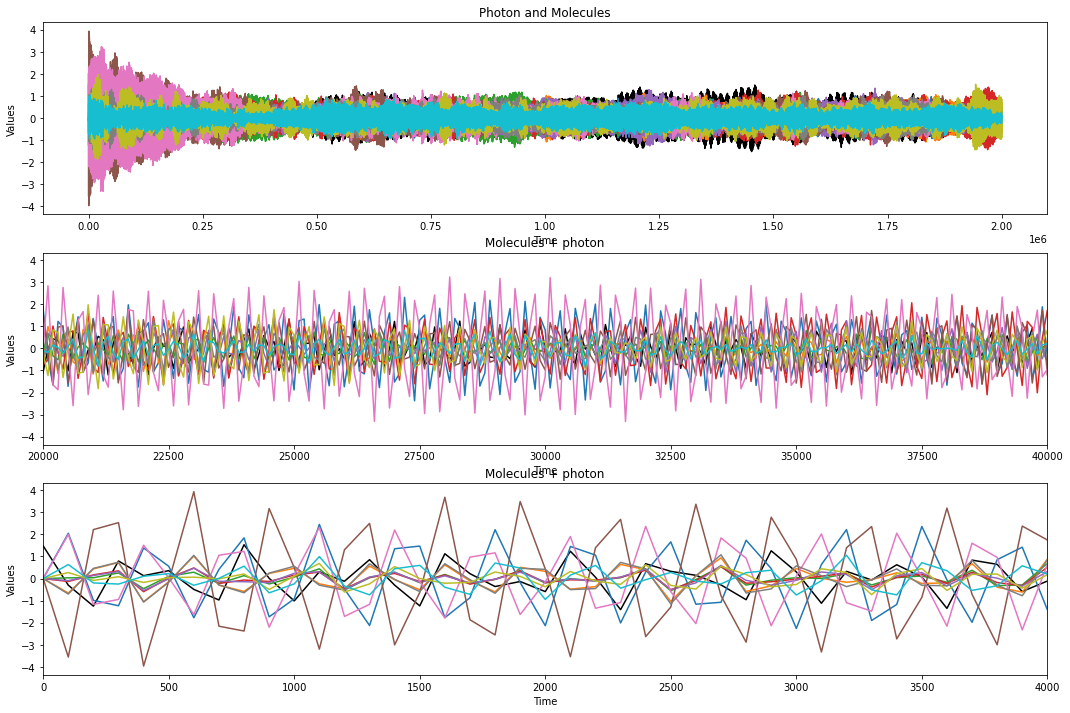

In [5]:
# Plot the results
plt.figure(figsize=[18,12])
plt.title('Coupled Generalized Langevin eq with friction and stochastic term')

plt.subplot(3,1,1)
plt.title('Photon and Molecules')
plt.plot(time_points, xc_values_eq, label='xc(t)', color='black')
for i in range(num_mol):
    plt.plot(time_points, xm_values_eq[i], label=f'xm{i+1}(t)')
#plt.ylim(-4,8)
plt.xlabel('Time')
plt.ylabel('Values')

plt.subplot(3,1,2)
plt.title('Molecules + photon')
plt.plot(time_points, xc_values_eq, label='xc(t)', color='black')
for i in range(num_mol):
    plt.plot(time_points, xm_values_eq[i], label=f'xm{i+1}(t)')
#plt.ylim(-10,10)
plt.xlim(20000,40000)
plt.xlabel('Time')
plt.ylabel('Values')

plt.subplot(3,1,3)
plt.title('Molecules + photon')
plt.plot(time_points, xc_values_eq, label='xc(t)', color='black')
for i in range(num_mol):
    plt.plot(time_points, xm_values_eq[i], label=f'xm{i+1}(t)')
#plt.ylim(-5,5)
plt.xlim(-1.0,4000)
plt.xlabel('Time')
plt.ylabel('Values')

#plt.legend()

plt.show()

Check last values of position and velocities and see if they are consistent with the temperature

In [6]:
system_consistent = check_temperature_consistency(vc_values_eq, vm_values_eq, kT, num_mol)


Time-averaged <v^2> for photon: 1.680143921160786e-05
Average <v^2> for molecules: 1.5311937850536695e-05
Combined average <v^2> for system (photon + molecules): 1.5447347065179526e-05
Expected <v^2> from temperature (kT): 9.44e-06
The time-averaged velocities of the photon and molecules are NOT consistent with the initial temperature.


Once the system has thermalized, we can use the final velocites and positions as the new initial conditions for a next dynamics calculation. Since the equilibration run was carried out without parametric drive of the cavity and with no interactions between molecules and photon, we also redifined the initial parameters by adding the parametric drive of the cavity.

In [7]:
''' PARAMETERS '''

# Set up parameters
wc = 0.0161#0.01376 
wm = 0.0161 # freqs au of the CH sym stretch in CHCl3
# Set up friction coefficients k, lamb and random kick sigma: 
k    = 5.46e-6
lamb = 5.46e-6
E0 = 2*k*wc**2 #0.0005 # Amplitude of driving laser
param_cav = [wc, E0]  # wc, E
freqs = np.random.normal(wm, 0.0002, num_mol)  # wm
print(freqs)
gamma = 0.0000/np.sqrt(num_mol) # light-matter coupling
param_mol = freqs.tolist() + [gamma] # wm, gamma


kT   = 0.000944*0.0 # 9.44x10⁻4 au is value of room temperature energy 25,7 meV
sigma_c = np.sqrt(2*kT*k/mu)
sigma_m = np.sqrt(2*kT*lamb/mu)

[0.01610201 0.0157448  0.01637306 0.01600101 0.016112   0.01608117
 0.01615806 0.01641512 0.01614525 0.01625609]


In [8]:
''' New initial conditions'''

# Molecules
init_xm = xm_values_eq[:,-1]
init_vm = vm_values_eq[:,-1]

# Photon 
init_xc = xc_values_eq[-1]
init_vc = vc_values_eq[-1]

# Combine initial conditions into a single list
init_cond = [init_xc, init_vc] + init_xm.tolist() + init_vm.tolist()


# Define time pointsp
t_final = 800000
t_step   = 100
time_points = np.arange(0, t_final, t_step)  # Time points from 0 to 10

# Solve the system using Velocity-Verlet algorithm
xc_values, vc_values, xm_values, vm_values = velocity_verlet(init_cond, time_points, num_mol, param_cav, param_mol)

# Solve the uncoupled system for comparison
param_mol = freqs.tolist() + [0]
xc_values_u, vc_values_u, xm_values_u, vm_values_u = velocity_verlet(init_cond, time_points, num_mol, param_cav, param_mol)

Define bright state as $x_{B} = \frac{1}{\sqrt{N}}\sum_{m} x_{m}$.

In [9]:
xb = np.empty(len(time_points))

for i in range(0,len(time_points)):
    xb[i] = 1/np.sqrt(num_mol) * np.sum(xm_values[:,i])


Compute position autocorrelation functions of $x_m$, $x_c$ and $x_B$.

In [10]:
# Molecular position autocorrelation function
C_xmxm = np.zeros((len(xm_values), len(time_points)))

for mol in range(len(xm_values)):
    C_xmxm[mol] = xm_values[mol,0]*xm_values[mol,:]/xm_values[mol,0]**2

#C_xmxm_fac = xm_values / xm_values[:, 0:1] # Alternatively one can use this super compact version but I think it's harder to read

# Photon position autocorrelation function
C_xcxc = xc_values[0]*xc_values / xc_values[0]**2 

#print(np.allclose(C_xmxm, C_xmxm_fac))

C_xbxb = xb[0]*xb / xb[0]**2




Compute same autocorrelation functions for the uncoupled system, $\gamma=0$

In [11]:
# Molecular position autocorrelation function
C_xmxm_u = np.zeros((len(xm_values_u), len(time_points)))

for mol in range(len(xm_values_u)):
    C_xmxm_u[mol] = xm_values_u[mol,0]*xm_values_u[mol,:]/xm_values_u[mol,0]**2

# Photon position autocorrelation function
C_xcxc_u = xc_values_u[0]*xc_values_u / xc_values_u[0]**2 

#print(np.allclose(C_xmxm, C_xmxm_fac))

#C_xbxb = xb[0]*xb / xb[0]**2

Plot the dynamics:

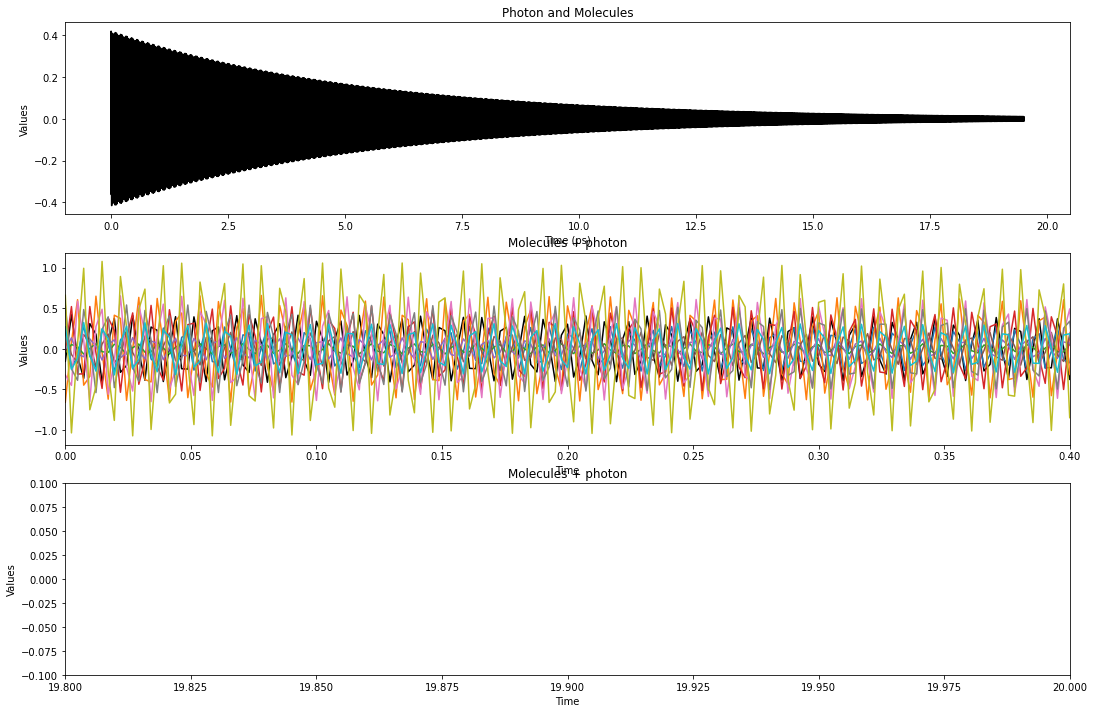

In [12]:

# Plot the results
plt.figure(figsize=[18,12])
plt.title('Coupled Generalized Langevin eq with friction and stochastic term')

plt.subplot(3,1,1)
plt.title('Photon and Molecules')
plt.plot(time_points/41000, xc_values, label='xc(t)', color='black')
#for i in range(num_mol):
#    plt.plot(time_points/41000, xm_values[i], label=f'xm{i+1}(t)')
#plt.xlim(4000,5000)
#plt.xticks(np.arange(0, t_final+1, 100))
plt.xlabel('Time (ps)')
plt.ylabel('Values')

plt.subplot(3,1,2)
plt.title('Molecules + photon')
plt.plot(time_points/41000, xc_values, label='xc(t)', color='black')
for i in range(num_mol):
    plt.plot(time_points/41000, xm_values[i], label=f'xm{i+1}(t)')
#plt.ylim(-10,10)
plt.xlim(0,0.4)
plt.xlabel('Time')
plt.ylabel('Values')

plt.subplot(3,1,3)
plt.title('Molecules + photon')
plt.plot(time_points/41000, xc_values, label='xc(t)', color='black')
for i in range(num_mol):
    plt.plot(time_points/41000, xm_values[i], label=f'xm{i+1}(t)')
plt.ylim(-0.1,0.1)
plt.xlim(19.8,20)
plt.xlabel('Time')
plt.ylabel('Values')

#plt.legend()

plt.show()




Analyse the frequencies of the oscillators by performing FFT. Use only last part of the signal, when the dynamics has reached a steady state.  

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from heapq import nlargest
import os 

# Compute FFTs and frequencies for xm_values and xc_values
fft_xm = [np.fft.fft(xm) for xm in C_xmxm]
fftfreq_xm = [2*np.pi*np.fft.fftfreq(fft.shape[-1], d=t_step) for fft in fft_xm]

fft_xm_late = [np.fft.fft(xm[-100000:]) for xm in C_xmxm]
fftfreq_xm_late = [2*np.pi*np.fft.fftfreq(fft.shape[-1], d=t_step) for fft in fft_xm_late]
av_fft_late = np.mean(fft_xm_late, axis=0)

fft_xm_early = [np.fft.fft(xm[:20000]) for xm in C_xmxm]
fftfreq_xm_early = [2*np.pi*np.fft.fftfreq(fft.shape[-1], d=t_step) for fft in fft_xm_early]

fft_xc = np.fft.fft(C_xcxc)
fftfreq_xc = 2*np.pi*np.fft.fftfreq(fft_xc.shape[-1], d=t_step)

fft_xc_late = np.fft.fft(C_xcxc[-10000:])
fftfreq_xc_late = 2*np.pi*np.fft.fftfreq(fft_xc_late.shape[-1], d=t_step)

fft_xc_early = np.fft.fft(C_xcxc[:20000])
fftfreq_xc_early = 2*np.pi*np.fft.fftfreq(fft_xc_early.shape[-1], d=t_step)

fft_xb = np.fft.fft(C_xbxb)
fftfreq_xb = 2*np.pi*np.fft.fftfreq(fft_xb.shape[-1], d=t_step)

fft_xb_late = np.fft.fft(C_xbxb[-100000:])
fftfreq_xb_late = 2*np.pi*np.fft.fftfreq(fft_xb_late.shape[-1], d=t_step)

fft_xb_early = np.fft.fft(C_xbxb[:20000])
fftfreq_xb_early = 2*np.pi*np.fft.fftfreq(fft_xb_early.shape[-1], d=t_step)

# Compute frequencies of the uncoupled system

fft_xm_u = [np.fft.fft(xm) for xm in C_xmxm_u]
fftfreq_xm_u = [2*np.pi*np.fft.fftfreq(fft.shape[-1], d=t_step) for fft in fft_xm_u]
av_fft_u = np.mean(fft_xm_u, axis=0)

fft_xc_u = np.fft.fft(C_xcxc_u)
fftfreq_xc_u = 2*np.pi*np.fft.fftfreq(fft_xc.shape[-1], d=t_step)


# Find main frequencies for xm_values late
main_frequencies_late = []
for i, fft_late in enumerate(fft_xm_late):
    ampl = np.abs(fft_late)
    peaks, _ = find_peaks(ampl)
    top_peak = nlargest(1, peaks, key=lambda i: ampl[i])
    main_freq_late = fftfreq_xm_late[i][top_peak]
    main_frequencies_late.append(main_freq_late)
    print(f'Main frequency for xm_values[{i}] (late):', main_freq_late)
print('main_frequencies:', main_frequencies_late)



# Save the averaged spectra in a txt file 
#np.savetxt('av_fft_u', np.abs(av_fft_u.real))
#np.savetxt('fftfreq_u', fftfreq_xm_u[0])

#np.savetxt('av_fft_late', np.abs(av_fft_late.real))
#np.savetxt('fftfreq_late', fftfreq_xm_late[0])

Main frequency for xm_values[0] (late): [0.01898307]
Main frequency for xm_values[1] (late): [0.01871604]
Main frequency for xm_values[2] (late): [0.01812699]
Main frequency for xm_values[3] (late): [0.01918728]
Main frequency for xm_values[4] (late): [-0.0185511]
Main frequency for xm_values[5] (late): [0.0187396]
Main frequency for xm_values[6] (late): [0.01868462]
Main frequency for xm_values[7] (late): [0.01881029]
Main frequency for xm_values[8] (late): [0.01925796]
Main frequency for xm_values[9] (late): [-0.01879458]
main_frequencies: [array([0.01898307]), array([0.01871604]), array([0.01812699]), array([0.01918728]), array([-0.0185511]), array([0.0187396]), array([0.01868462]), array([0.01881029]), array([0.01925796]), array([-0.01879458])]


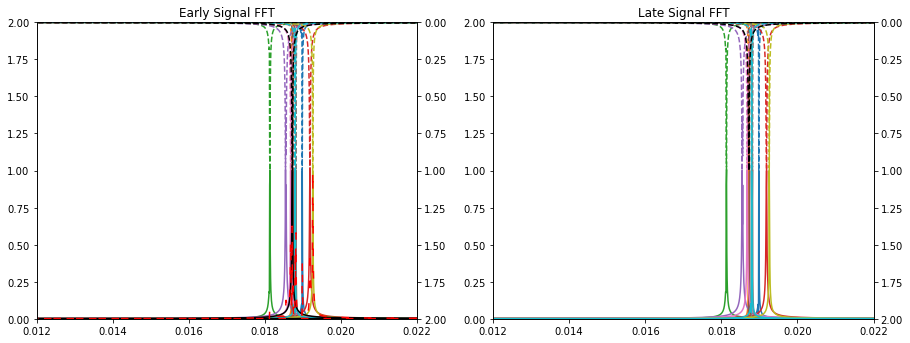

In [15]:


# Plot results
plt.figure(figsize=[15, 12])
# Plot for all frequencies
ax = plt.subplot(2, 2, 1)
for i in range(len(fft_xm)):
    ax.plot(fftfreq_xm_early[i], np.abs(fft_xm_early[i].real)/np.max(np.abs(fft_xm_early[i].real)), label=f'xm_values[{i}]')
ax.plot(fftfreq_xc_early, np.abs(fft_xc_early.real)/np.max(np.abs(fft_xc_early.real)), color='black', label='xc_values')
ax.plot(fftfreq_xb_early, np.abs(fft_xb_early.real)/np.max(np.abs(fft_xb_early.real)), color='red', linestyle=(0, (5, 10)), label='xb_values')
ax.set_xlim(0.012, 0.022)
ax.set_ylim(0.0, 2.0)
ax.set_title("Early Signal FFT")
#ax.legend(loc=4)

ax2 = ax.twinx()
for i in range(len(fft_xm_u)):
    ax2.plot(fftfreq_xm_u[i], np.abs(fft_xm_u[i].real)/np.max(np.abs(fft_xm_u[i].real)), label=f'xm_values[{i}] uncoupled', linestyle='--')
ax2.plot(fftfreq_xc_u, np.abs(fft_xc_u.real)/np.max(np.abs(fft_xc_u.real)), color='black', linestyle='--', label='xc uncoupled')
ax2.set_ylim(0.0, 2.0)
ax2.invert_yaxis()  # Flip the secondary y-axis
#ax2.legend(loc=1)

# Plot for late signal frequencies
ax = plt.subplot(2, 2, 2)
for i in range(len(fft_xm_late)):
    ax.plot(fftfreq_xm_late[i], np.abs(fft_xm_late[i].real)/np.max(np.abs(fft_xm_late[i].real)), label=f'xm_values[{i}] Late')
#ax.plot(fftfreq_xm_late[0], np.abs(av_fft_late.real)/np.max(np.abs(av_fft_late.real)), label=f'average xm_values Late')
#for i in range(len(main_frequencies_late)):
#    ax.axvline(x=np.abs(main_frequencies_late[i]), linestyle='dashed')
#ax.plot(fftfreq_xc_late, np.abs(fft_xc_late.real)/np.max(np.abs(fft_xc_late.real)), color='black', label='xc_values Late')
#plt.plot(fftfreq_xb_late, np.abs(fft_xb_late.real)/np.max(np.abs(fft_xb_late.real)), color='gray', label='xb_values Late')
ax.set_xlim(0.012, 0.022)
ax.set_ylim(0.0, 2.0)
ax.set_title("Late Signal FFT")

ax2 = ax.twinx()
for i in range(len(fft_xm_u)):
    ax2.plot(fftfreq_xm_u[i], np.abs(fft_xm_u[i].real)/np.max(np.abs(fft_xm_u[i].real)), label=f'xm_values[{i}] uncoupled', linestyle='--')
#ax2.plot(fftfreq_xm_u[0], np.abs(av_fft_u.real)/np.max(np.abs(av_fft_u.real)), label=f'average xm_values uncoupled', linestyle='--')
ax2.plot(fftfreq_xc_u, np.abs(fft_xc_u.real)/np.max(np.abs(fft_xc_u.real)), color='black', linestyle='--', label='xc_values uncoupled (flipped)')
ax2.set_ylim(0.0, 2.0)
ax2.invert_yaxis()  # Flip the secondary y-axis
#plt.legend()

plt.savefig('spectra.png', format='png', dpi=300) 
plt.show()
